In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer     # Helps to apply different preprocessing steps to different columns of the dataset (Apply StandardScaler to numerical columns and OneHotEncoder to categorical columns.)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

In [2]:
df= pd.read_csv(r"C:\Users\USER\OneDrive\Desktop\Loan-Credit-Analytics\dataset\Loan_Dataset.csv")
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Applicant_ID', 'Gender', 'Age', 'Marital_Status', 'Dependents', 'Education', 'Employment_Status', 'Occupation_Type', 'Residential_Status', 'City/Town', 'Annual_Income', 'Monthly_Expenses', 'Credit_Score', 'Existing_Loans', 'Total_Existing_Loan_Amount', 'Outstanding_Debt', 'Loan_History', 'Loan_Amount_Requested', 'Loan_Term', 'Loan_Purpose', 'Interest_Rate', 'Loan_Type', 'Co-Applicant', 'Bank_Account_History', 'Transaction_Frequency', 'Default_Risk', 'Loan_Approval_Status']


In [3]:
selected_features = [
    "Credit_Score",
    "Loan_Amount_Requested",
    "Annual_Income",
    "Age",
    "Interest_Rate",
    "Outstanding_Debt",
    "Monthly_Expenses"
]

X = df[selected_features]
y = df["Loan_Approval_Status"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (52000, 7)
Target shape: (52000,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (41600, 7)
Testing: (10400, 7)


In [5]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), selected_features)
    ]
)

In [6]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [7]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_roc_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1 Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_roc_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.8504
Precision: 0.85
Recall   : 0.9311
F1 Score : 0.8887
ROC-AUC  : 0.8148


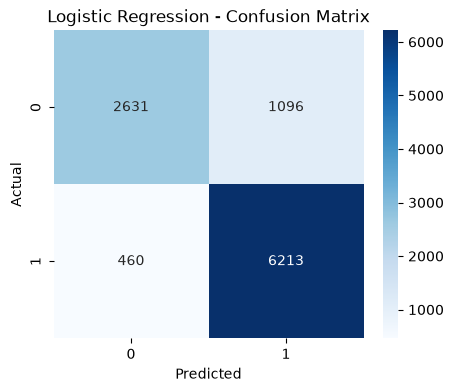

In [8]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of **85.04%** on the test dataset. The model obtained a precision of **85.00%**, recall of **93.11%**, and an F1-score of **88.87%**.

The ROC-AUC score of **81.48%** indicates that the model has a reasonable ability to distinguish between approved and rejected loan applications.

Overall, Logistic Regression provides consistent predictive performance on the test dataset. It achieved a marginally higher recall than the Random Forest model, indicating that it correctly identified a slightly larger proportion of approved applications.

In [9]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

In [10]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_roc_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_roc_auc, 4))

Random Forest
-------------
Accuracy : 0.8508
Precision: 0.8507
Recall   : 0.9308
F1 Score : 0.8889
ROC-AUC  : 0.8188


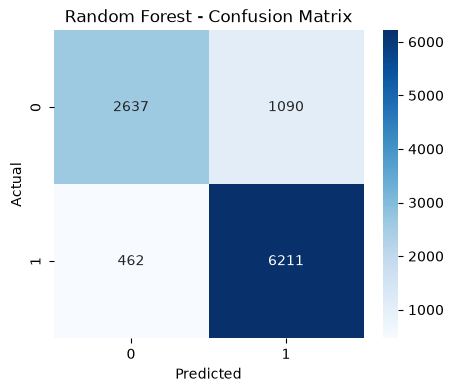

In [11]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Random Forest Evaluation

The Random Forest classifier achieved an accuracy of **85.08%** on the test dataset. It obtained a precision of **85.07%**, recall of **93.08%**, and an F1-score of **88.89%**.

The ROC-AUC score of **81.88%** indicates that the model has a reasonable ability to distinguish between approved and rejected loan applications.

The Random Forest model performed slightly better than Logistic Regression in terms of accuracy, precision, F1-score, and ROC-AUC, while Logistic Regression achieved a marginally higher recall.

Overall, the Random Forest model demonstrated consistent predictive performance using the seven selected features and was selected as the final model for the Loan Approval Prediction System.

In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Logistic Regression": [
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1,
        lr_roc_auc
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_roc_auc
    ]
})

comparison

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.850385,0.850769
1,Precision,0.850048,0.850705
2,Recall,0.931065,0.930766
3,F1 Score,0.888714,0.888937
4,ROC-AUC,0.814834,0.818787


In [13]:
rf_classifier = random_forest_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": rf_classifier.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance["Importance (%)"] = (
    feature_importance["Importance"] * 100
)

feature_importance

,Feature,Importance,Importance (%)
0,Credit_Score,0.289155,28.915487
1,Loan_Amount_Requested,0.224180,22.418029
2,Annual_Income,0.149703,14.970314
5,Outstanding_Debt,0.088255,8.825477
6,Monthly_Expenses,0.087427,8.742674
4,Interest_Rate,0.085466,8.546573
3,Age,0.075814,7.581447


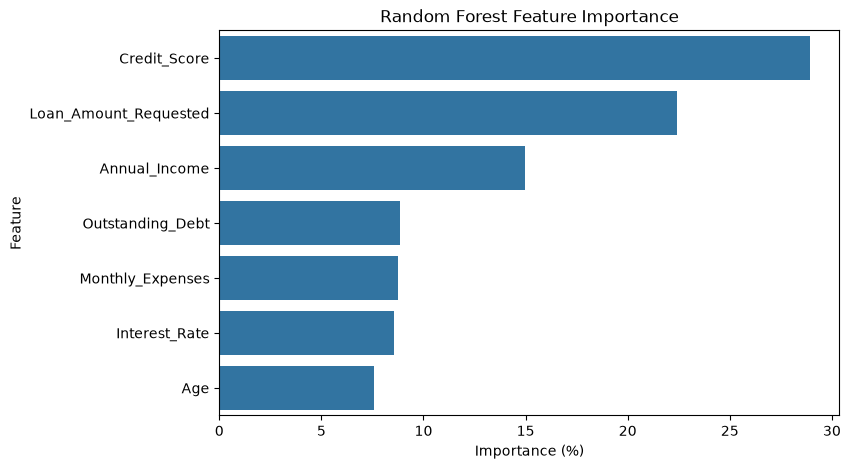

In [14]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance,
    x="Importance (%)",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.show()

### Feature Importance

The Random Forest model identifies **Credit Score** as the most important feature for predicting loan approval, with an importance of approximately **28.92%**. **Loan Amount Requested** and **Annual Income** are the next most influential features, with importance values of approximately **22.42%** and **14.97%**, respectively.

Other selected features include **Outstanding Debt (8.83%)**, **Monthly Expenses (8.74%)**, **Interest Rate (8.55%)**, and **Age (7.58%)**.

The feature importance results indicate that the Random Forest model considers multiple applicant and loan-related financial characteristics when generating predictions. Feature importance represents the model's reliance on these variables and does not imply that a feature directly causes loan approval.

In [15]:
os.makedirs("../models", exist_ok=True)

model_path = "../models/loan_approval_random_forest_7features.pkl"

joblib.dump(
    random_forest_model,
    model_path
)

print("Model saved:", model_path)

Model saved: ../models/loan_approval_random_forest_7features.pkl


In [16]:
new_applicant = pd.DataFrame({
    "Credit_Score": [750],
    "Loan_Amount_Requested": [25000],
    "Annual_Income": [90000],
    "Age": [35],
    "Interest_Rate": [7.5],
    "Outstanding_Debt": [10000],
    "Monthly_Expenses": [3000]
})

prediction = random_forest_model.predict(new_applicant)[0]

probability = random_forest_model.predict_proba(
    new_applicant
)[0][1]

result = "Approved" if prediction == 1 else "Rejected"

print("Prediction:", result)
print("Approval Probability:", round(probability * 100, 2), "%")

Prediction: Approved
Approval Probability: 81.5 %


## New Applicant Prediction

A sample applicant was provided to the trained Random Forest model to demonstrate the loan approval prediction workflow.

The model predicted the applicant as **Approved** with an approval probability of **81.5%**.

The prediction was generated using the seven selected features: Credit Score, Loan Amount Requested, Annual Income, Age, Interest Rate, Outstanding Debt, and Monthly Expenses.

This demonstrates how the trained model can be used to evaluate a new loan application based on selected applicant and loan-related financial characteristics.